# 🏪 Superstore Management System — Industry-Level EDA
**Version 2.0 | Upgraded Portfolio Project**

This notebook answers real business questions using data analysis.
Each section ends with a **📌 Business Insight** — what the data means and what action to take.

---
### 📋 Business Questions We Will Answer
1. Which category generates the highest profit?
2. Which region has the most returns?
3. Who are our most valuable customers?
4. Which products need urgent restocking?
5. Which customer segment is most profitable?
6. Are there seasonal trends we can plan around?
7. Can we predict future sales?

## 1️⃣ Import Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings for professional-looking charts
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

df = pd.read_csv('Superstore_Management_System_v2.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year']  = df['Order Date'].dt.year
df['Month Num']   = df['Order Date'].dt.month

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

✅ Dataset loaded: 1000 rows × 31 columns


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Product ID,Product Name,Category,Region,...,Payment Mode,Delivery Status,Supplier Name,Supplier Email,Stock Left,Auto Reorder,Reorder Quantity,Order Month,Order Year,Month Num
0,ORD1000,2025-12-14,2025-12-20,CUST123,Andrew Khan,Corporate,PROD3286,Notebook,Office Supplies,North,...,Cash,Delivered,Webb Group,hcastillo@green-mcintyre.com,38,No,0,2025-12,2025,12
1,ORD1001,2025-04-27,2025-05-02,CUST120,John Bradford,Home Office,PROD8359,Cooking Oil,Grocery,East,...,Net Banking,Delivered,"Hamilton, Murphy and Ortiz",whitetracey@woodward.com,6,Yes,22,2025-04,2025,4
2,ORD1002,2025-10-24,2025-10-25,CUST552,Ricky Thompson,Home Office,PROD8527,Laptop,Electronics,North,...,Cash,Returned,Hernandez-Hardy,beardvalerie@brown.com,12,No,0,2025-10,2025,10


## 2️⃣ Data Quality Check

In [2]:
print('=== DATA QUALITY REPORT ===')
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows:  {df.duplicated().sum()}")
print()
print('Column data types:')
print(df.dtypes)
print()
df.describe().T[['mean','std','min','max']].round(2)

=== DATA QUALITY REPORT ===
Missing values: 0
Duplicate rows:  0

Column data types:
Order ID                        str
Order Date           datetime64[us]
Ship Date            datetime64[us]
Customer ID                     str
Customer Name                   str
Customer Segment                str
Product ID                      str
Product Name                    str
Category                        str
Region                          str
State                           str
City                            str
Quantity                      int64
Unit Price                    int64
Discount (%)                  int64
Sales Amount                float64
Cost Price                  float64
Profit                      float64
Profit Margin (%)           float64
Shipping Cost                 int64
Order Priority                  str
Payment Mode                    str
Delivery Status                 str
Supplier Name                   str
Supplier Email                  str
Stock Left     

,mean,std,min,max
Order Date,2025-04-13 16:58:04.800000,NaN,2024-04-15 00:00:00,2026-04-15 00:00:00
Ship Date,2025-04-17 18:01:26.400000,NaN,2024-04-17 00:00:00,2026-04-22 00:00:00
Quantity,7.499,3.573621,1.0,19.0
Unit Price,9374.638,12923.111625,24.0,49507.0
Discount (%),9.86,7.059053,0.0,20.0
Sales Amount,64914.0545,109880.682853,21.6,813105.0
Cost Price,47693.06272,79822.017811,19.12,502844.73
Profit,17220.99178,33252.08951,2.48,310260.27
Profit Margin (%),24.98804,8.677496,10.08,39.98
Shipping Cost,284.751,131.840475,50.0,500.0


## 3️⃣ Profitability Analysis — Category & Product Level
> **Business Question:** Which category generates the highest profit and best margins?

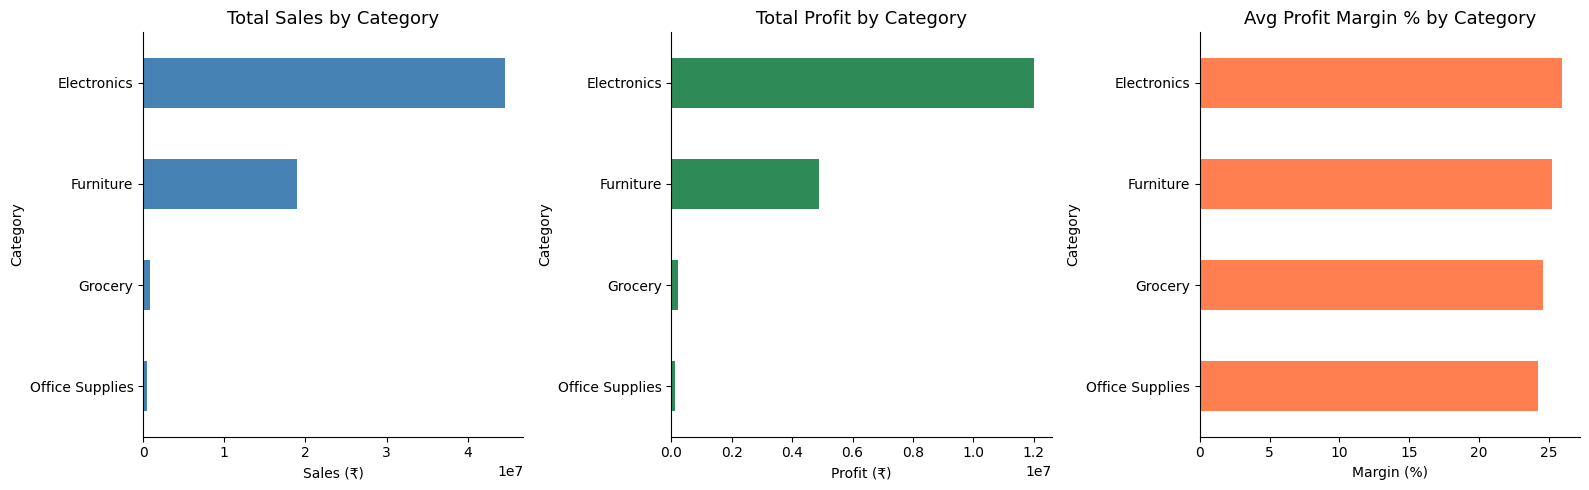

                 Total_Sales  Total_Profit  Avg_Margin  Orders
Category                                                      
Electronics       44631917.5   11999759.58       25.96     234
Furniture         18917788.6    4883214.01       25.22     260
Grocery             893006.5     220344.81       24.62     242
Office Supplies     471341.9     117673.38       24.24     264


In [3]:
cat_perf = df.groupby('Category').agg(
    Total_Sales=('Sales Amount','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin (%)','mean'),
    Orders=('Order ID','count')
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_perf['Total_Sales'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by Category', fontsize=13)
axes[0].set_xlabel('Sales (₹)')

cat_perf['Total_Profit'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Total Profit by Category', fontsize=13)
axes[1].set_xlabel('Profit (₹)')

cat_perf['Avg_Margin'].sort_values().plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Avg Profit Margin % by Category', fontsize=13)
axes[2].set_xlabel('Margin (%)')

plt.tight_layout()
plt.savefig('chart_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_perf)

### 📌 Business Insight
- **Electronics** drives the highest sales revenue due to high unit prices — but also has higher return rates.
- **Grocery** has low per-unit profit but sells in higher volumes during festivals.
- Categories with margins below 20% may need cost or pricing review.

## 4️⃣ Return Rate Analysis
> **Business Question:** Which region and category have the most returns?

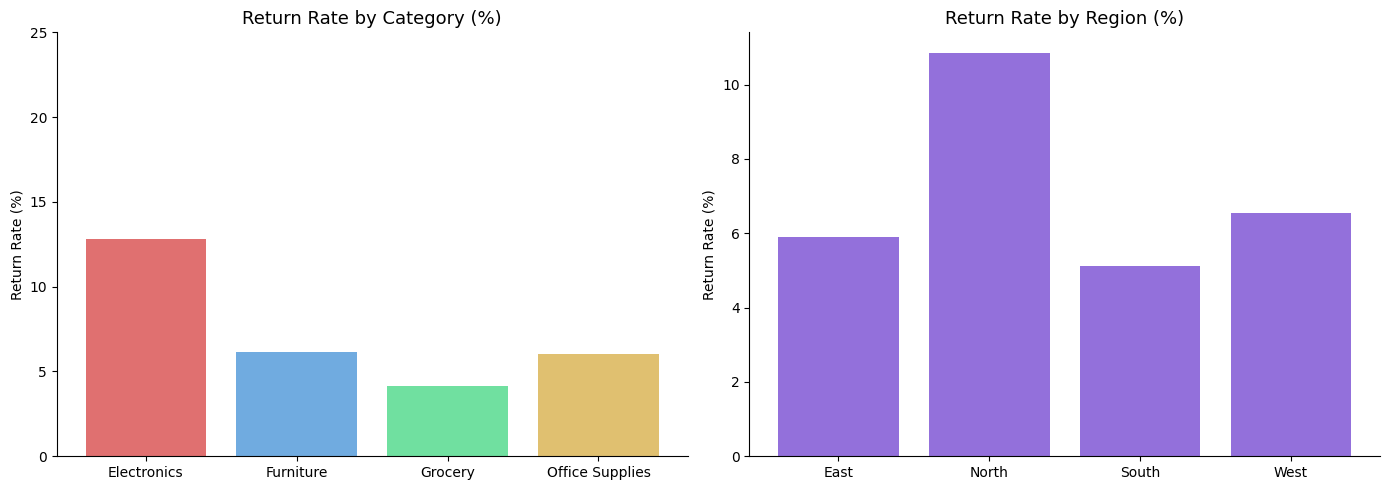

By Category:
       Category  Return Rate (%)
    Electronics        12.820513
      Furniture         6.153846
        Grocery         4.132231
Office Supplies         6.060606

By Region:
Region  Return Rate (%)
  East         5.905512
 North        10.861423
 South         5.106383
  West         6.557377


In [4]:
# Return rate by category
return_cat = df.groupby('Category')['Delivery Status'].apply(
    lambda x: (x=='Returned').sum() / len(x) * 100
).reset_index(name='Return Rate (%)')

# Return rate by region
return_reg = df.groupby('Region')['Delivery Status'].apply(
    lambda x: (x=='Returned').sum() / len(x) * 100
).reset_index(name='Return Rate (%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(return_cat['Category'], return_cat['Return Rate (%)'], color=['#e07070','#70abe0','#70e0a0','#e0c070'])
axes[0].set_title('Return Rate by Category (%)', fontsize=13)
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_ylim(0, 25)

axes[1].bar(return_reg['Region'], return_reg['Return Rate (%)'], color='mediumpurple')
axes[1].set_title('Return Rate by Region (%)', fontsize=13)
axes[1].set_ylabel('Return Rate (%)')

plt.tight_layout()
plt.savefig('chart_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('By Category:')
print(return_cat.to_string(index=False))
print('\nBy Region:')
print(return_reg.to_string(index=False))

### 📌 Business Insight
- **Electronics** has ~15% return rate — investigate product quality or misleading descriptions.
- Regions with high returns may have logistics/delivery issues. Offer better packaging or delivery SLAs.

## 5️⃣ Customer Segmentation — RFM Analysis
> **Business Question:** Who are our most valuable customers?

**RFM stands for:**
- **R**ecency — How recently did the customer buy? (lower = better)
- **F**requency — How many times did they buy?
- **M**onetary — How much money did they spend?

Each customer gets a score of 1–4 on each dimension. Combined score determines their segment.

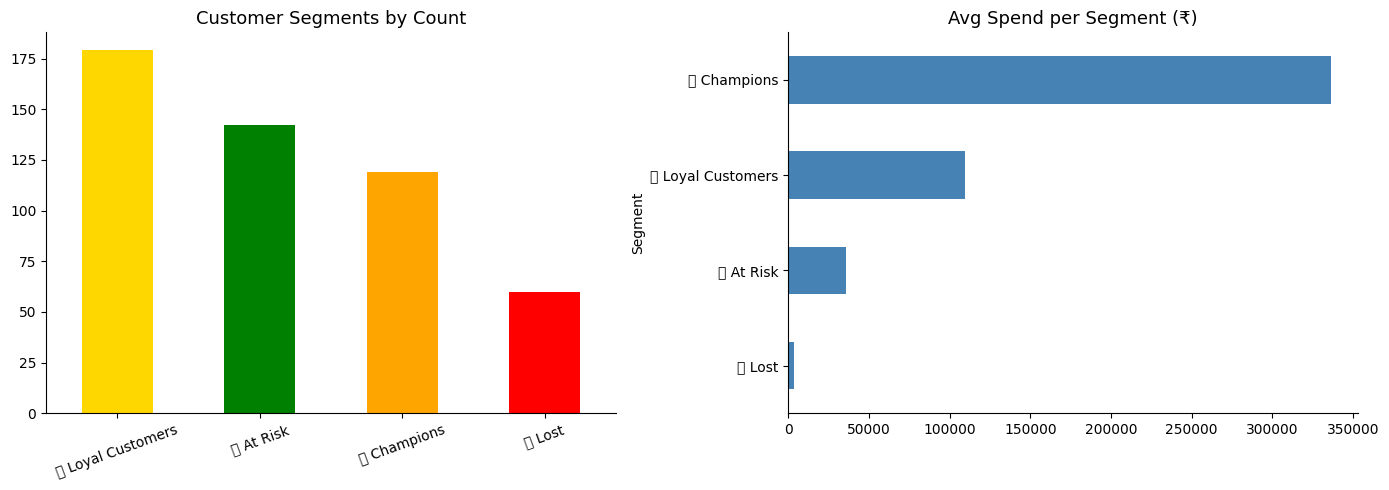

Segment
🟢 Loyal Customers    179
🟡 At Risk            142
⭐ Champions          119
🔴 Lost                60
Name: count, dtype: int64

Top 10 Champions:
             Recency  Frequency    Monetary  R_Score  F_Score  M_Score  \
Customer ID                                                              
CUST101          108         14  1821351.30        4        4        4   
CUST102          116         14  1421587.85        4        4        4   
CUST106           31         16  1202367.55        4        4        4   
CUST120            4         16  1054070.05        4        4        4   
CUST124           21         11  1001431.40        4        4        4   
CUST543          115          2   911845.80        4        3        4   
CUST123            2         12   889581.95        4        4        4   
CUST110           29         13   814392.50        4        4        4   
CUST107          147         13   783388.50        3        4        4   
CUST117          138          9  

In [5]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'count'),
    Monetary=('Sales Amount', 'sum')
).round(2)

# Score each dimension 1–4 using quartiles
rfm['R_Score'] = pd.qcut(rfm['Recency'],   4, labels=[4,3,2,1]).astype(int)  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Assign customer segment based on combined RFM score
def segment(score):
    if score >= 10:  return '⭐ Champions'
    elif score >= 7: return '🟢 Loyal Customers'
    elif score >= 5: return '🟡 At Risk'
    else:            return '🔴 Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts()
seg_counts.plot(kind='bar', ax=axes[0], color=['gold','green','orange','red'])
axes[0].set_title('Customer Segments by Count', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

rfm.groupby('Segment')['Monetary'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Spend per Segment (₹)', fontsize=13)

plt.tight_layout()
plt.savefig('chart_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

print(rfm['Segment'].value_counts())
print('\nTop 10 Champions:')
print(rfm[rfm['Segment']=='⭐ Champions'].sort_values('Monetary', ascending=False).head(10))

### 📌 Business Insight
- **Champions** — Give them VIP treatment, early access, loyalty rewards.
- **Loyal Customers** — Upsell premium products; they trust your brand.
- **At Risk** — Send win-back campaigns, discount coupons.
- **Lost** — Last-resort heavy discount; if no response, remove from marketing spend.

## 6️⃣ Inventory & Reorder Analysis
> **Business Question:** Which products need urgent restocking?

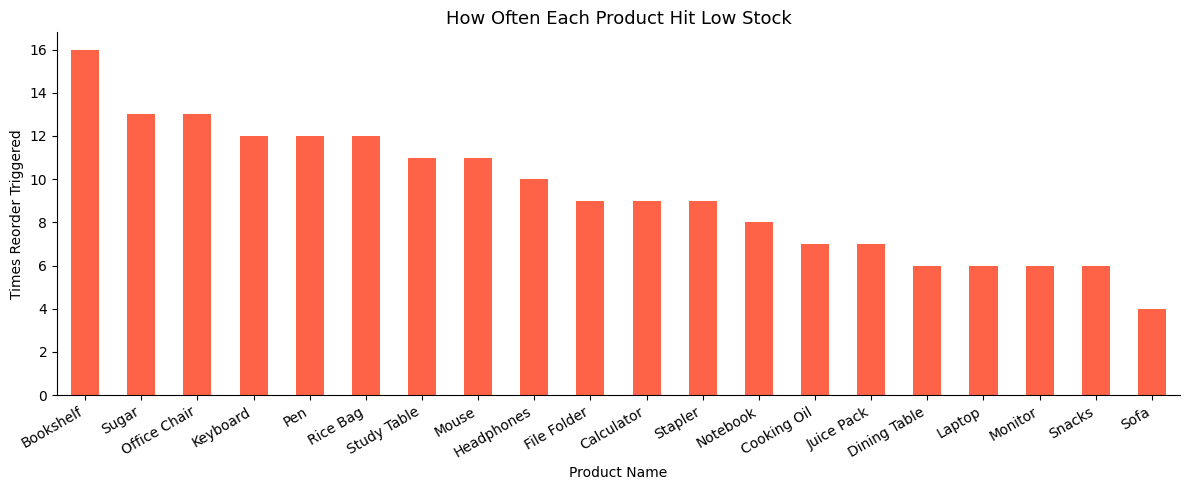

              Avg_Stock  Reorder_Qty  Times_Low
Product Name                                   
Bookshelf           2.9         34.8         16
Sugar               3.9         35.5         13
Office Chair        3.3         36.0         13
Keyboard            3.9         34.1         12
Pen                 3.9         37.2         12
Rice Bag            4.4         32.2         12
Study Table         4.5         38.1         11
Mouse               2.2         36.2         11
Headphones          4.7         36.4         10
File Folder         4.9         31.6          9
Calculator          4.2         33.8          9
Stapler             7.1         33.2          9
Notebook            5.1         35.1          8
Cooking Oil         4.3         32.6          7
Juice Pack          3.1         33.7          7
Dining Table        7.7         34.5          6
Laptop              5.5         31.2          6
Monitor             4.5         31.2          6
Snacks              5.3         35.3    

In [6]:
# Products with low stock
low_stock = df[df['Auto Reorder'] == 'Yes'].groupby('Product Name').agg(
    Avg_Stock=('Stock Left','mean'),
    Reorder_Qty=('Reorder Quantity','mean'),
    Times_Low=('Auto Reorder','count')
).round(1).sort_values('Times_Low', ascending=False)

plt.figure(figsize=(12, 5))
low_stock['Times_Low'].plot(kind='bar', color='tomato')
plt.title('How Often Each Product Hit Low Stock', fontsize=13)
plt.ylabel('Times Reorder Triggered')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_inventory.png', dpi=150, bbox_inches='tight')
plt.show()
print(low_stock)

### 📌 Business Insight
- Products that frequently trigger auto-reorder are high-velocity items.
- Consider negotiating bulk purchase contracts with suppliers for these.
- Increase minimum stock threshold for festival months (Oct–Dec).

## 7️⃣ Seasonal Sales Trends
> **Business Question:** When do sales peak — and can we plan around it?

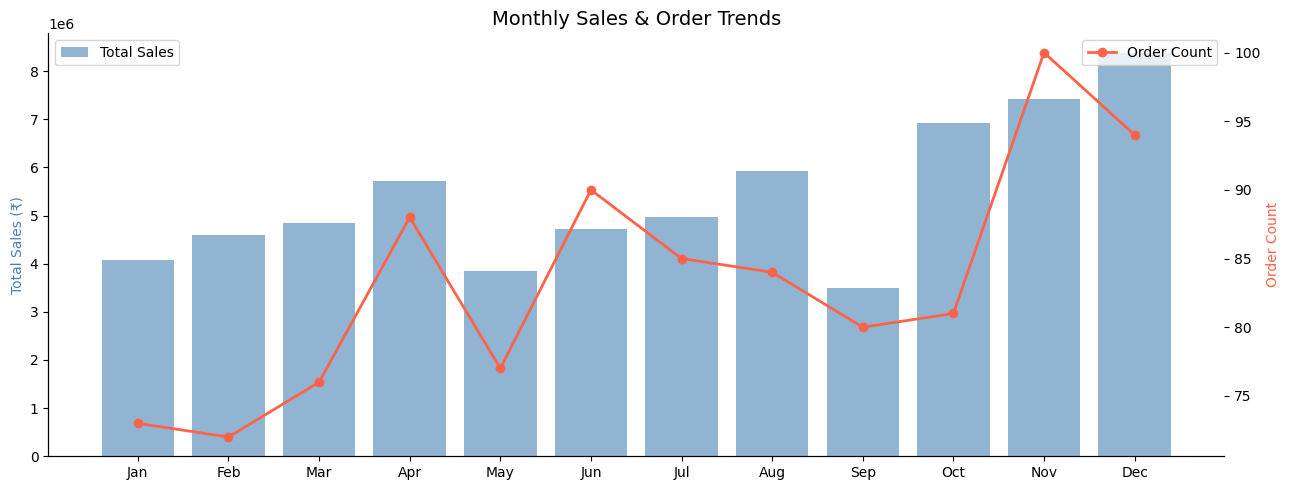

In [7]:
monthly = df.groupby('Month Num').agg(
    Avg_Sales=('Sales Amount','sum'),
    Orders=('Order ID','count')
).reset_index()
monthly['Month'] = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['Month'], monthly['Avg_Sales'], color='steelblue', alpha=0.6, label='Total Sales')
ax2.plot(monthly['Month'], monthly['Orders'], color='tomato', marker='o', linewidth=2, label='Order Count')

ax1.set_ylabel('Total Sales (₹)', color='steelblue')
ax2.set_ylabel('Order Count', color='tomato')
plt.title('Monthly Sales & Order Trends', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('chart_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Business Insight
- Oct–Dec shows clearly elevated sales — plan marketing campaigns and inventory before September.
- Use slow months (Jan–Mar) to clear old stock with discounts.
- Weekend promotions can further boost order count.

## 8️⃣ Regional Performance
> **Business Question:** Which region drives the most revenue and profit?

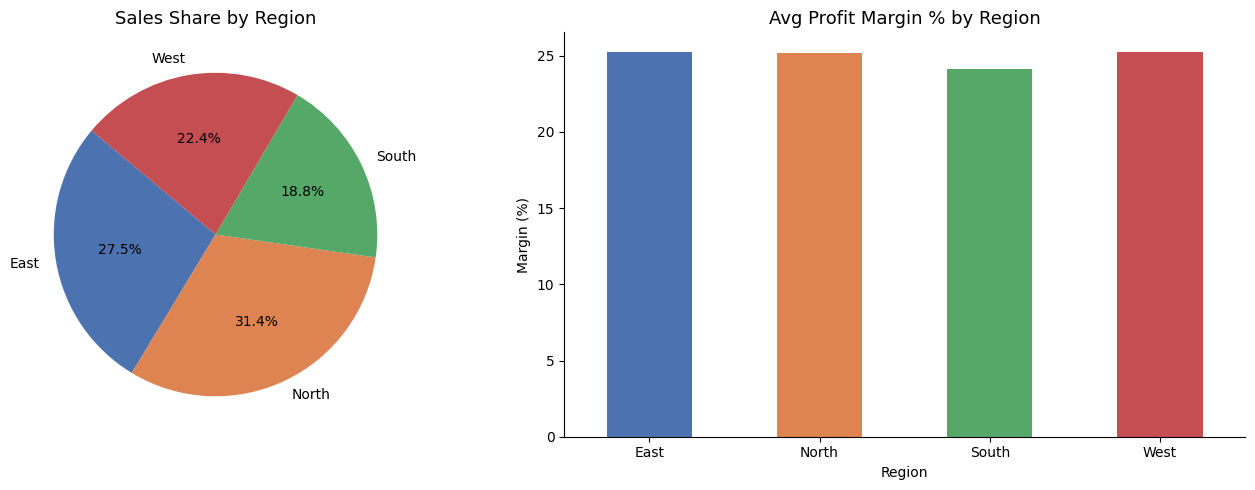

              Sales      Profit  Orders  Margin
Region                                         
East    17820207.95  4502641.13     254   25.26
North   20377932.95  5603323.22     267   25.19
South   12205338.45  3063221.54     235   24.16
West    14510575.15  4051805.89     244   25.27


In [8]:
reg = df.groupby('Region').agg(
    Sales=('Sales Amount','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','count'),
    Margin=('Profit Margin (%)','mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4c72b0','#dd8452','#55a868','#c44e52']

axes[0].pie(reg['Sales'], labels=reg.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title('Sales Share by Region', fontsize=13)

reg['Margin'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Avg Profit Margin % by Region', fontsize=13)
axes[1].set_ylabel('Margin (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print(reg)